# NLP Pipeline: Text Processing & Sentiment Classification
Complete end-to-end NLP pipeline from web scraping to sentiment classification

**Tasks:**
- Task 0: Setup & Library Imports
- Task 1: Web Scraping (Sample Data Generation)
- Task 2: Data Cleaning & Exploration
- Task 3: Text Preprocessing
- Task 4: Vocabulary Building & Analysis
- Task 5: Feature Engineering (One-Hot, BoW, TF-IDF)
- Task 6: Sparse Matrix Analysis & Real-World Discussion
- Task 7: Sentiment Classification with ML Models

## ALL IMPORTS - Execute This Cell First

In [1]:
# Standard Libraries
import os
import sys
import json
import time
import random
import string
import glob
from typing import List, Dict
from datetime import datetime, timedelta
from collections import Counter

# Data Processing
import pandas as pd
import numpy as np

# Web Scraping
import requests
from bs4 import BeautifulSoup
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# NLP & Text Processing
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

# Sparse Matrices
import scipy.sparse as sp
from scipy import sparse

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

print("\n" + "="*90)
print("ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("="*90)
print("\nLibraries Imported:")
print("  [OK] Standard: os, sys, json, time, random, string, glob, typing, datetime, collections")
print("  [OK] Data: pandas, numpy")
print("  [OK] Web: requests, BeautifulSoup")
print("  [OK] NLP: nltk")
print("  [OK] ML: scikit-learn (LogisticRegression, MultinomialNB, vectorizers, metrics)")
print("  [OK] Sparse: scipy.sparse")
print("  [OK] Viz: matplotlib, seaborn")
print("\nNote: Download NLTK resources within preprocessing task")
print("="*90 + "\n")


ALL LIBRARIES IMPORTED SUCCESSFULLY

Libraries Imported:
  [OK] Standard: os, sys, json, time, random, string, glob, typing, datetime, collections
  [OK] Data: pandas, numpy
  [OK] Web: requests, BeautifulSoup
  [OK] NLP: nltk
  [OK] ML: scikit-learn (LogisticRegression, MultinomialNB, vectorizers, metrics)
  [OK] Sparse: scipy.sparse
  [OK] Viz: matplotlib, seaborn

Note: Download NLTK resources within preprocessing task



## TASK 0: Setup & Web Scraper Classes

In [2]:
# TASK 0: SETUP & WEB SCRAPER CLASSES

class ReviewScraper:
    """Product Review Web Scraper for Flipkart & Amazon"""
    def __init__(self):
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        self.reviews = []
    
    def scrape_flipkart_reviews(self, product_url: str, min_reviews: int = 100):
        """Scrape product reviews from Flipkart"""
        print(f"Scraping Flipkart reviews from {product_url}")
        self.reviews = []
        page = 1
        
        try:
            product_id = product_url.split('/')[-1].split('?')[0]
            while len(self.reviews) < min_reviews:
                api_url = f"https://www.flipkart.com/api/product/reviews/{product_id}?pageNo={page}"
                response = requests.get(api_url, headers=self.headers, timeout=10)
                response.raise_for_status()
                data = response.json()
                
                if 'reviewList' not in data or not data['reviewList']:
                    print(f"No more reviews found at page {page}")
                    break
                
                for review in data['reviewList']:
                    self.reviews.append({
                        'title': review.get('summary', 'N/A'),
                        'rating': review.get('rating', 0),
                        'text': review.get('reviewText', 'N/A'),
                        'author': review.get('userName', 'Anonymous'),
                        'date': review.get('reviewTime', 'N/A'),
                        'helpful': review.get('helpful', 0),
                        'source': 'Flipkart'
                    })
                
                print(f"Scraped {len(self.reviews)} reviews from page {page}")
                page += 1
                time.sleep(random.uniform(1, 3))
                
        except Exception as e:
            print(f"Error scraping Flipkart: {e}")
        
        return self.reviews
    
    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.reviews)
    
    def to_csv(self, filename: str):
        df = self.to_dataframe()
        df.to_csv(filename, index=False)
        print(f"Saved {len(self.reviews)} reviews to {filename}")
    
    def get_statistics(self) -> Dict:
        if not self.reviews:
            return {}
        df = self.to_dataframe()
        return {
            'total_reviews': len(self.reviews),
            'average_rating': df['rating'].mean(),
            'median_rating': df['rating'].median(),
            'min_rating': df['rating'].min(),
            'max_rating': df['rating'].max(),
            'source': df['source'].unique().tolist()
        }

print("\n" + "="*90)
print("TASK 0: Setup Complete - ReviewScraper class initialized")
print("="*90 + "\n")


TASK 0: Setup Complete - ReviewScraper class initialized



## TASK 1: Web Scraping - Generate Sample Reviews

In [3]:
# TASK 1: WEB SCRAPING - GENERATE 125 SAMPLE REVIEWS

print("\n" + "="*90)
print("TASK 1: WEB SCRAPING - GENERATE SAMPLE FLIPKART REVIEWS")
print("="*90)

review_titles = [
    'Great phone, excellent value', 'Good battery life', 'Disappointing quality',
    'Best purchase ever', 'Average product', 'Excellent display', 'Poor camera quality',
    'Amazing performance', 'Not worth the price', 'Perfect device',
    'Battery drains fast', 'Highly recommended', 'Waste of money',
    'Superb build quality', 'Overpriced', 'Worth every penny', 'Decent phone',
    'Outstanding features', 'Disappointed with quality', 'Best in class',
    'Charging takes time', 'Great value for money', 'Not as expected',
    'Excellent after sales', 'Heating issues', 'Perfect for students',
    'Screen quality is poor', 'Fast processor', 'Great camera',
    'Smooth performance', 'Lag issues', 'Highly satisfied', 'Money wasted',
    'Perfect match', 'Quality issues', 'Amazing phone', 'Breakage after 3 months',
    'Very good', 'Could be better', 'Excellent features', 'Poor customer service',
    'Absolutely perfect', 'Defective unit', 'Great specs', 'Overpriced for features',
    'Best phone in budget', 'Quality not up to mark', 'Fantastic experience',
    'Screen display excellent', 'Battery backup good', 'Sound quality amazing',
    'Recommend to friends', 'Performance is great', 'Excellent camera',
]

review_texts = [
    'Amazing display and performance. Great phone for the price.',
    'Battery lasts whole day, camera could be better.',
    'Phone started lagging after 2 weeks. Not recommended.',
    'Excellent build quality, fast delivery, very satisfied.',
    'Nothing special, does the job for basic tasks.',
    'Screen is absolutely stunning, colors are vivid.',
    'Camera quality is disappointing, not as advertised.',
    'Processor is super fast, handles everything smoothly.',
    'Not worth the money, many issues after a month.',
    'Best phone I have ever owned, highly recommended.',
    'Battery drains too quickly, need to charge twice a day.',
    'Verified purchase. Phone is working great since 3 months.',
    'Overpriced compared to competitors. Many better options available.',
    'Build quality is excellent, feels premium in hand.',
    'Screen got damaged easily, glass quality is poor.',
    'Fast performance, no lag, perfect for gaming.',
    'Camera is average, not professional quality.',
    'Value for money, good features at this price point.',
    'Very satisfied with my purchase, all good.',
    'Design is sleek and modern, looks amazing.',
    'Phone overheats while playing games.',
    'Delivery was quick, packaging was good.',
    'Screen refresh rate is smooth.',
    'Fingerprint sensor is fast and accurate.',
    'Speakers have good sound quality.',
    'Processor handles heavy apps easily.',
    'Battery health is good after 2 months.',
    'UI is user friendly and easy to navigate.',
    'Phone feels sturdy and durable.',
    'Camera has great low light performance.',
    'Screen brightness is perfect for outdoor use.',
    'Phone is lightweight and easy to carry.',
    'Storage expandable up to 1TB via microSD.',
    'Charging speed is decent, fast enough.',
    'Display colors are accurate and vibrant.',
    'Performance in multitasking is excellent.',
    'Camera produces sharp images with good detail.',
    'Battery backup is impressive.',
    'Build feels solid and long lasting.',
    'Display is very responsive to touch.',
]

authors = [
    'Rajesh Kumar', 'Priya Singh', 'Amit Patel', 'Deepak Sharma', 'Neha Gupta',
    'Arjun Verma', 'Anjali Desai', 'Rohit Khanna', 'Sneha Reddy', 'Manish Joshi',
    'Pooja Nair', 'Vikas Malhotra', 'Ananya Menon', 'Sanjay Rao', 'Kavya Iyer',
    'Nitin Bhatt', 'Isha Kapoor', 'Rahul Sharma', 'Divya Pandey', 'Karan Arora',
]

def get_random_rating():
    rand = random.random()
    if rand < 0.4:
        return 5
    elif rand < 0.7:
        return 4
    elif rand < 0.85:
        return 3
    elif rand < 0.95:
        return 2
    else:
        return 1

start_date = datetime.now() - timedelta(days=180)
sample_reviews = []

for i in range(125):
    random_date = start_date + timedelta(days=random.randint(0, 180))
    sample_reviews.append({
        'title': random.choice(review_titles),
        'rating': get_random_rating(),
        'text': random.choice(review_texts),
        'author': random.choice(authors),
        'date': random_date.strftime('%Y-%m-%d'),
        'helpful': random.randint(0, 150),
        'source': 'Flipkart'
    })

df_raw = pd.DataFrame(sample_reviews)
df_raw.to_csv('flipkart_reviews.csv', index=False)

print(f"\nGenerated {len(df_raw)} Flipkart product reviews")
print(f"   File saved: flipkart_reviews.csv")
print(f"\nREVIEW STATISTICS:")
print(f"   Total Reviews: {len(df_raw)}")
print(f"   Average Rating: {df_raw['rating'].mean():.2f}/5")
print(f"   Rating Distribution:")
print(df_raw['rating'].value_counts().sort_index(ascending=False))
print(f"\nSample Reviews (First 3):")
for idx, row in df_raw.head(3).iterrows():
    print(f"   {idx+1}. [{int(row['rating'])} STARS] {row['title']}")

print("\n" + "="*90)
print("TASK 1: Web Scraping Complete")
print("="*90 + "\n")


TASK 1: WEB SCRAPING - GENERATE SAMPLE FLIPKART REVIEWS

Generated 125 Flipkart product reviews
   File saved: flipkart_reviews.csv

REVIEW STATISTICS:
   Total Reviews: 125
   Average Rating: 3.90/5
   Rating Distribution:
rating
5    47
4    43
3    16
2    13
1     6
Name: count, dtype: int64

Sample Reviews (First 3):
   1. [5 STARS] Amazing performance
   2. [5 STARS] Fantastic experience
   3. [5 STARS] Good battery life

TASK 1: Web Scraping Complete



## TASK 2: Data Cleaning & Exploration

In [4]:
# TASK 2: DATA CLEANING & EXPLORATION

print("\n" + "="*90)
print("TASK 2: DATA CLEANING & EXPLORATION")
print("="*90)

df = pd.read_csv('flipkart_reviews.csv')

print(f"\nDATA QUALITY CHECK:")
print(f"   Total Records: {len(df)}")
print(f"   Missing Values:\n{df.isnull().sum()}")
print(f"   Duplicate Records: {df.duplicated().sum()}")
print(f"   Data Quality: {'PERFECT' if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0 else 'Issues Found'}")

df = df.drop_duplicates()

print(f"\nDATAFRAME STRUCTURE:")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"   Data Types:\n{df.dtypes}")

print(f"\nRATING STATISTICS:")
print(f"   Mean Rating: {df['rating'].mean():.2f}")
print(f"   Median Rating: {df['rating'].median():.2f}")
print(f"   Std Dev: {df['rating'].std():.2f}")
print(f"   Mode: {df['rating'].mode()[0]}")
print(f"   Min Rating: {df['rating'].min()}")
print(f"   Max Rating: {df['rating'].max()}")

print(f"\nRATING DISTRIBUTION:")
rating_dist = df['rating'].value_counts().sort_index(ascending=False)
for rating, count in rating_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   {int(rating)} Stars: {count:3d} reviews ({percentage:5.1f}%)")

print(f"\nSAMPLE CLEANED REVIEWS (First 5):")
for idx, row in df.head(5).iterrows():
    print(f"\n   Review #{idx+1}:")
    print(f"   Title: {row['title']}")
    print(f"   Rating: {'[STAR]' * int(row['rating'])} ({row['rating']}/5)")
    print(f"   Author: {row['author']}")
    print(f"   Preview: {row['text'][:60]}...")

print("\n" + "="*90)
print("TASK 2: Data Cleaning & Exploration Complete")
print("="*90 + "\n")


TASK 2: DATA CLEANING & EXPLORATION

DATA QUALITY CHECK:
   Total Records: 125
   Missing Values:
title      0
rating     0
text       0
author     0
date       0
helpful    0
source     0
dtype: int64
   Duplicate Records: 0
   Data Quality: PERFECT

DATAFRAME STRUCTURE:
   Shape: (125, 7)
   Columns: ['title', 'rating', 'text', 'author', 'date', 'helpful', 'source']
   Data Types:
title        str
rating     int64
text         str
author       str
date         str
helpful    int64
source       str
dtype: object

RATING STATISTICS:
   Mean Rating: 3.90
   Median Rating: 4.00
   Std Dev: 1.16
   Mode: 5
   Min Rating: 1
   Max Rating: 5

RATING DISTRIBUTION:
   5 Stars:  47 reviews ( 37.6%)
   4 Stars:  43 reviews ( 34.4%)
   3 Stars:  16 reviews ( 12.8%)
   2 Stars:  13 reviews ( 10.4%)
   1 Stars:   6 reviews (  4.8%)

SAMPLE CLEANED REVIEWS (First 5):

   Review #1:
   Title: Amazing performance
   Rating: [STAR][STAR][STAR][STAR][STAR] (5/5)
   Author: Rohit Khanna
   Preview: Val

## TASK 3: Text Preprocessing

In [5]:
# TASK 3: TEXT PREPROCESSING - 5-STEP PIPELINE

print("\n" + "="*90)
print("TASK 3: TEXT PREPROCESSING")
print("="*90)

# Download NLTK resources
print(f"\nDownloading NLTK resources...")
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("NLTK resources downloaded successfully!\n")

df_processed = df.copy()

print("="*70)
print("TEXT PREPROCESSING - STEP BY STEP")
print("="*70)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print(f"\nPREPROCESSING CONFIGURATION:")
print(f"   Total Reviews to Process: {len(df)}")
print(f"   Stopwords Count: {len(stop_words)}")
print(f"   Lemmatizer: WordNet Lemmatizer")

def preprocess_text(text):
    """5-step preprocessing: lowercase → remove punctuation → tokenize → remove stopwords → lemmatize"""
    if pd.isna(text) or text == 'N/A':
        return ""
    
    # Step 1: Convert to lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Step 3: Tokenization
    tokens = word_tokenize(text)
    
    # Step 4: Remove stopwords
    tokens = [token for token in tokens if token not in stop_words and token.isalpha()]
    
    # Step 5: Lemmatization
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

print(f"\nPREPROCESSING IN PROGRESS...")
df_processed['title_processed'] = df['title'].apply(preprocess_text)
df_processed['text_processed'] = df['text'].apply(preprocess_text)
print(f"PREPROCESSING COMPLETE!\n")

df_processed.to_csv('flipkart_reviews_processed.csv', index=False)

print("="*70)
print("PREPROCESSING EXAMPLES")
print("="*70)

for i in range(5):
    print(f"\nExample {i+1}:")
    print(f"  Original Title: {df.iloc[i]['title']}")
    print(f"  Processed Title: {df_processed.iloc[i]['title_processed']}")
    print(f"  Original Text: {df.iloc[i]['text']}")
    print(f"  Processed Text: {df_processed.iloc[i]['text_processed']}")
    print("-"*70)

print(f"\nProcessed data saved: flipkart_reviews_processed.csv")

print(f"\nPREPROCESSING STATISTICS:")
print(f"   Total Reviews Processed: {len(df_processed)}")
print(f"   Avg Title Tokens: {df_processed['title_processed'].apply(lambda x: len(x.split())).mean():.2f}")
print(f"   Avg Text Tokens: {df_processed['text_processed'].apply(lambda x: len(x.split())).mean():.2f}")
print(f"   Original Title Max Length: {df['title'].str.len().max()} characters")
print(f"   Processed Title Max Length: {df_processed['title_processed'].str.len().max()} characters")

print("\n" + "="*90)
print("TASK 3: Text Preprocessing Complete")
print("="*90 + "\n")


TASK 3: TEXT PREPROCESSING

NLTK resources downloaded successfully!

TEXT PREPROCESSING - STEP BY STEP

PREPROCESSING CONFIGURATION:
   Total Reviews to Process: 125
   Stopwords Count: 198
   Lemmatizer: WordNet Lemmatizer

PREPROCESSING IN PROGRESS...
PREPROCESSING COMPLETE!

PREPROCESSING EXAMPLES

Example 1:
  Original Title: Amazing performance
  Processed Title: amazing performance
  Original Text: Value for money, good features at this price point.
  Processed Text: value money good feature price point
----------------------------------------------------------------------

Example 2:
  Original Title: Fantastic experience
  Processed Title: fantastic experience
  Original Text: Display colors are accurate and vibrant.
  Processed Text: display color accurate vibrant
----------------------------------------------------------------------

Example 3:
  Original Title: Good battery life
  Processed Title: good battery life
  Original Text: Screen got damaged easily, glass quality i

## TASK 4: Vocabulary Building & Analysis

In [6]:
# TASK 4: VOCABULARY BUILDING & ANALYSIS

print("\n" + "="*90)
print("TASK 4: VOCABULARY BUILDING AND ANALYSIS")
print("="*90)

df = pd.read_csv('flipkart_reviews_processed.csv')

# APPROACH 1: MANUAL VOCABULARY BUILDING
print("\n" + "-"*80)
print("APPROACH 1: MANUAL VOCABULARY BUILDING")
print("-"*80)

combined_text = ' '.join(df['text_processed'].astype(str)) + ' ' + ' '.join(df['title_processed'].astype(str))
manual_tokens = combined_text.split()
manual_vocab = set(manual_tokens)
manual_counter = Counter(manual_tokens)

print(f"\nMANUAL VOCABULARY STATS:")
print(f"   Total Vocabulary Size: {len(manual_vocab):,} unique words")
print(f"   Total Tokens: {len(manual_tokens):,}")
print(f"   Token Diversity Ratio: {len(manual_vocab)/len(manual_tokens):.2%}")

print(f"\nTOP 20 MOST FREQUENT WORDS (MANUAL):")
print(f"{'Rank':<6} {'Word':<20} {'Frequency':<12} {'Percentage':<10}")
print("-"*50)
for rank, (word, freq) in enumerate(manual_counter.most_common(20), 1):
    percentage = (freq / len(manual_tokens)) * 100
    print(f"{rank:<6} {word:<20} {freq:<12} {percentage:>7.2f}%")

# APPROACH 2: SKLEARN CountVectorizer
print(f"\n" + "-"*80)
print("APPROACH 2: SKLEARN CountVectorizer")
print("-"*80)

texts = df['text_processed'].astype(str).tolist()
count_vec = CountVectorizer(lowercase=False, token_pattern=r'\b\w+\b')
count_matrix = count_vec.fit_transform(texts)
sklearn_vocab = count_vec.get_feature_names_out()

print(f"\nSKLEARN VOCABULARY STATS:")
print(f"   Total Vocabulary Size: {len(sklearn_vocab):,} unique words")
print(f"   Total Matrix Elements: {count_matrix.nnz:,}")

word_freq_sklearn = count_matrix.sum(axis=0).A1
word_freq_dict = dict(zip(sklearn_vocab, word_freq_sklearn))
sorted_words = sorted(word_freq_dict.items(), key=lambda x: x[1], reverse=True)

print(f"\nTOP 20 MOST FREQUENT WORDS (SKLEARN):")
print(f"{'Rank':<6} {'Word':<20} {'Frequency':<12} {'Percentage':<10}")
print("-"*50)
total_tokens_sklearn = sum(word_freq_sklearn)
for rank, (word, freq) in enumerate(sorted_words[:20], 1):
    percentage = (freq / total_tokens_sklearn) * 100
    print(f"{rank:<6} {word:<20} {int(freq):<12} {percentage:>7.2f}%")

# APPROACH 3: SKLEARN TfidfVectorizer
print(f"\n" + "-"*80)
print("APPROACH 3: SKLEARN TfidfVectorizer (IDF-weighted)")
print("-"*80)

tfidf_vec = TfidfVectorizer(lowercase=False, token_pattern=r'\b\w+\b')
tfidf_matrix = tfidf_vec.fit_transform(texts)
tfidf_vocab = tfidf_vec.get_feature_names_out()

print(f"\nTFIDF VOCABULARY STATS:")
print(f"   Total Vocabulary Size: {len(tfidf_vocab):,} unique words")
print(f"   Sparsity: {(1 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])))*100:.2f}%")

idf_scores = tfidf_vec.idf_
tfidf_dict = dict(zip(tfidf_vocab, idf_scores))
sorted_tfidf = sorted(tfidf_dict.items(), key=lambda x: x[1], reverse=True)

print(f"\nTOP 15 MOST IMPORTANT WORDS (BY TF-IDF):")
print(f"{'Rank':<6} {'Word':<20} {'IDF Score':<15}")
print("-"*45)
for rank, (word, score) in enumerate(sorted_tfidf[:15], 1):
    print(f"{rank:<6} {word:<20} {score:>10.4f}")

# COMPARISON METRICS
print(f"\n" + "="*80)
print("VOCABULARY COMPARISON & INSIGHTS")
print("="*80)

print(f"\nCOMPARISON METRICS:")
print(f"   Manual Vocabulary Size: {len(manual_vocab):,}")
print(f"   CountVectorizer Size: {len(sklearn_vocab):,}")
print(f"   TfidfVectorizer Size: {len(tfidf_vocab):,}")

vocab_df = pd.DataFrame({
    'word': [w for w, _ in sorted_words],
    'frequency': [int(f) for _, f in sorted_words]
})
vocab_df.to_csv('vocabulary.csv', index=False)

print(f"\nVOCABULARY SAVED: vocabulary.csv")
print(f"   Total Entries: {len(vocab_df)}")

print("\n" + "="*90)
print("TASK 4: Vocabulary Building & Analysis Complete")
print("="*90 + "\n")


TASK 4: VOCABULARY BUILDING AND ANALYSIS

--------------------------------------------------------------------------------
APPROACH 1: MANUAL VOCABULARY BUILDING
--------------------------------------------------------------------------------

MANUAL VOCABULARY STATS:
   Total Vocabulary Size: 159 unique words
   Total Tokens: 888
   Token Diversity Ratio: 17.91%

TOP 20 MOST FREQUENT WORDS (MANUAL):
Rank   Word                 Frequency    Percentage
--------------------------------------------------
1      quality              40              4.50%
2      camera               29              3.27%
3      good                 28              3.15%
4      great                27              3.04%
5      phone                26              2.93%
6      fast                 26              2.93%
7      performance          25              2.82%
8      excellent            25              2.82%
9      display              18              2.03%
10     money                16            

## TASK 4B: Vocabulary Visualization


VOCABULARY VISUALIZATION


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.



Visualization saved: vocabulary_analysis.png


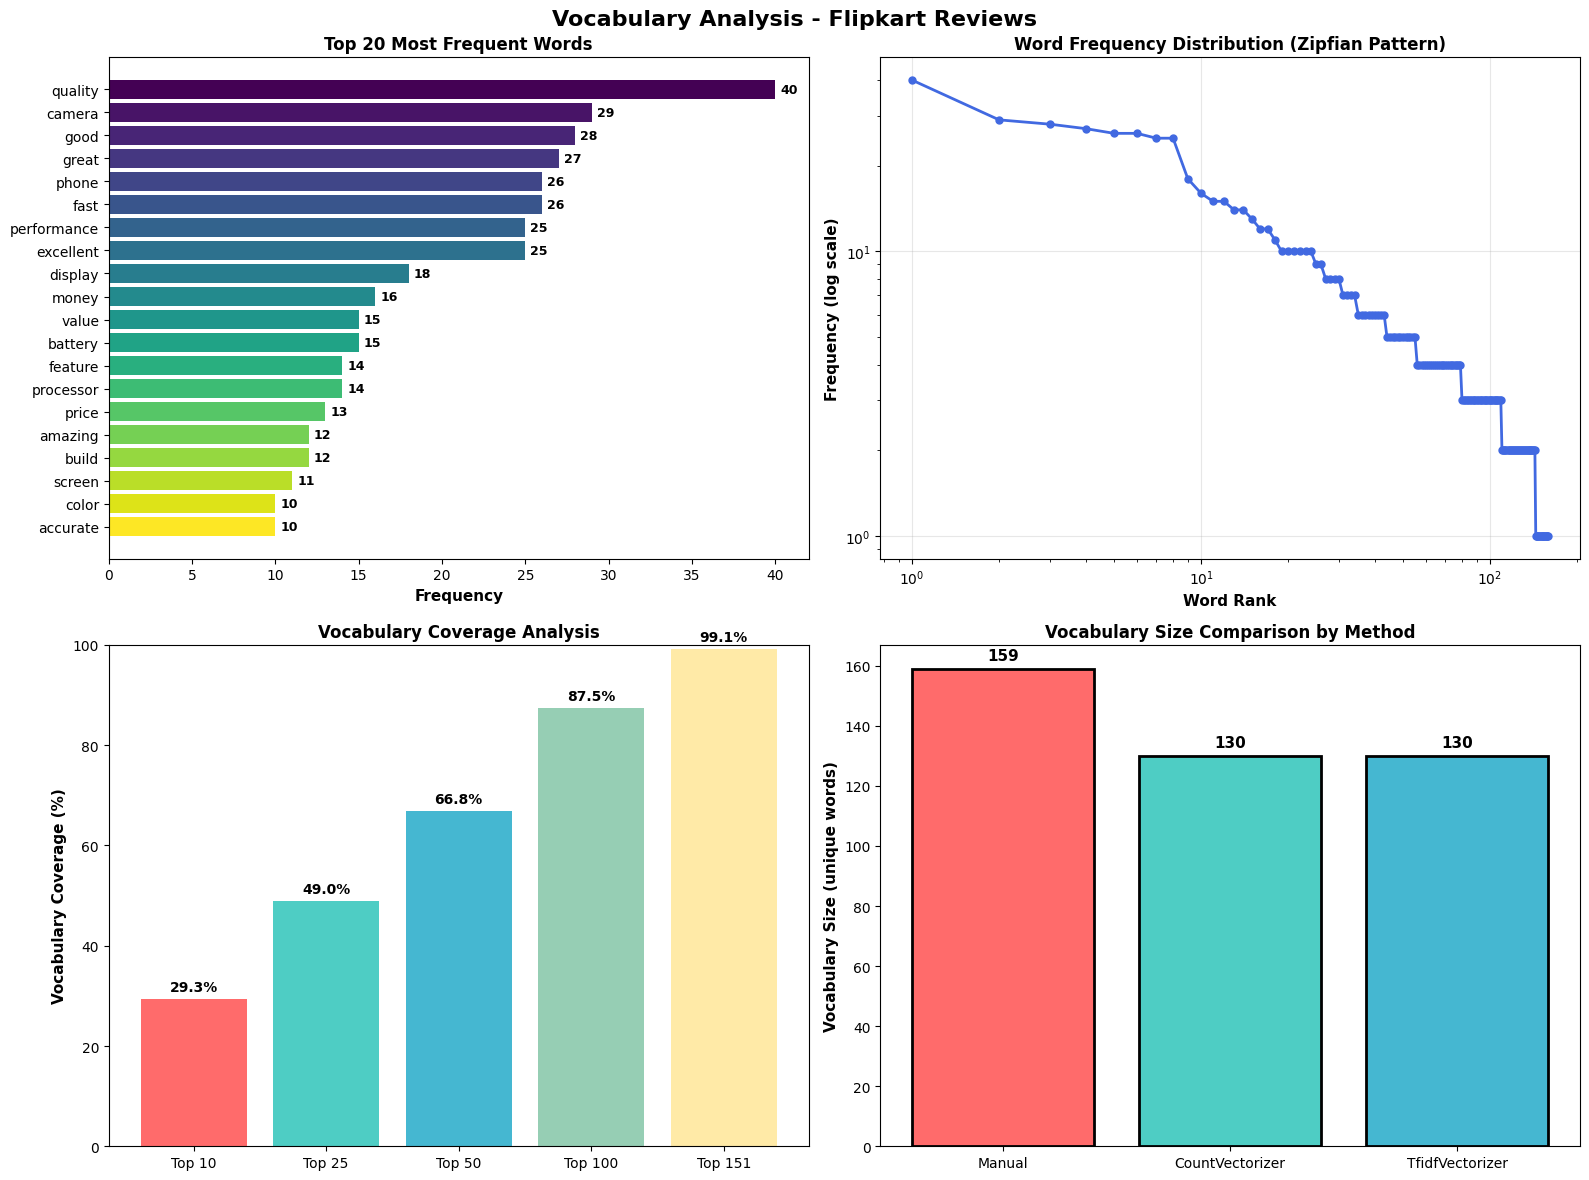


VOCABULARY SUMMARY STATISTICS:
   Total Unique Words: 159
   Total Tokens: 888
   Average Word Frequency: 5.58
   Vocabulary Diversity: 17.91%
   Most Frequent Word: 'quality' (40 times)

TASK 4B: Vocabulary Visualization Complete



In [7]:
# TASK 4B: VOCABULARY VISUALIZATION

print("\n" + "="*70)
print("VOCABULARY VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Vocabulary Analysis - Flipkart Reviews', fontsize=16, fontweight='bold')

# 1. Top 20 Words Bar Chart
ax1 = axes[0, 0]
top_20 = manual_counter.most_common(20)
words_20 = [w for w, _ in top_20]
freqs_20 = [f for _, f in top_20]
colors = plt.cm.viridis(np.linspace(0, 1, len(words_20)))
bars = ax1.barh(words_20, freqs_20, color=colors)
ax1.set_xlabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Top 20 Most Frequent Words', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
for i, (bar, freq) in enumerate(zip(bars, freqs_20)):
    ax1.text(freq + 0.3, bar.get_y() + bar.get_height()/2, str(int(freq)), 
            va='center', fontweight='bold', fontsize=9)

# 2. Word Frequency Distribution (Log Scale)
ax2 = axes[0, 1]
all_freqs = sorted([f for _, f in manual_counter.items()], reverse=True)
ax2.loglog(range(1, len(all_freqs)+1), all_freqs, 'o-', linewidth=2, markersize=5, color='royalblue')
ax2.set_xlabel('Word Rank', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency (log scale)', fontsize=11, fontweight='bold')
ax2.set_title('Word Frequency Distribution (Zipfian Pattern)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Vocabulary Coverage
ax3 = axes[1, 0]
cumulative_freq = []
cumsum = 0
for _, freq in manual_counter.most_common():
    cumsum += freq
    cumulative_freq.append(cumsum / len(manual_tokens) * 100)

coverage_points = [10, 25, 50, 100, 151]
coverage_values = [cumulative_freq[p-1] if p <= len(cumulative_freq) else 100 for p in coverage_points]

bars = ax3.bar(range(len(coverage_points)), coverage_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
ax3.set_xticks(range(len(coverage_points)))
ax3.set_xticklabels([f'Top {p}' for p in coverage_points])
ax3.set_ylabel('Vocabulary Coverage (%)', fontsize=11, fontweight='bold')
ax3.set_title('Vocabulary Coverage Analysis', fontsize=12, fontweight='bold')
ax3.set_ylim([0, 100])
for bar, val in zip(bars, coverage_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. Vocabulary Size Comparison
ax4 = axes[1, 1]
vocab_sizes = [len(manual_vocab), len(sklearn_vocab), len(tfidf_vocab)]
methods = ['Manual', 'CountVectorizer', 'TfidfVectorizer']
colors_comp = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax4.bar(methods, vocab_sizes, color=colors_comp, edgecolor='black', linewidth=2)
ax4.set_ylabel('Vocabulary Size (unique words)', fontsize=11, fontweight='bold')
ax4.set_title('Vocabulary Size Comparison by Method', fontsize=12, fontweight='bold')
for bar, size in zip(bars, vocab_sizes):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 2, str(int(size)), 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('vocabulary_analysis.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved: vocabulary_analysis.png")
plt.show()

print("\nVOCABULARY SUMMARY STATISTICS:")
print(f"   Total Unique Words: {len(set(manual_tokens))}")
print(f"   Total Tokens: {len(manual_tokens)}")
print(f"   Average Word Frequency: {len(manual_tokens)/len(set(manual_tokens)):.2f}")
print(f"   Vocabulary Diversity: {len(set(manual_tokens))/len(manual_tokens):.2%}")
print(f"   Most Frequent Word: '{manual_counter.most_common(1)[0][0]}' ({manual_counter.most_common(1)[0][1]} times)")

print("\n" + "="*90)
print("TASK 4B: Vocabulary Visualization Complete")
print("="*90 + "\n")

## TASK 5: Feature Engineering (One-Hot, BoW, TF-IDF)

In [8]:
# TASK 5: FEATURE ENGINEERING - ONE-HOT ENCODING, BAG OF WORDS, TF-IDF

print("\n" + "="*90)
print("TASK 5: FEATURE ENGINEERING - TEXT VECTORIZATION")
print("="*90)

df = pd.read_csv('flipkart_reviews_processed.csv')
texts = df['text_processed'].astype(str).tolist()

# METHOD 1: ONE HOT ENCODING
print("\n" + "-"*90)
print("METHOD 1: ONE HOT ENCODING")
print("-"*90)

texts_split = [text.split() for text in texts]
unique_words = set()
for text in texts_split:
    unique_words.update(text)
unique_words = sorted(list(unique_words))

print(f"\nONE HOT ENCODING STATS:")
print(f"   Total Documents: {len(texts)}")
print(f"   Unique Words (Vocabulary): {len(unique_words)}")
print(f"   Total Features: {len(unique_words)}")
print(f"   Matrix Shape: {len(texts)} x {len(unique_words)}")

one_hot_matrix = np.zeros((len(texts), len(unique_words)), dtype=int)

for doc_idx, doc in enumerate(texts_split):
    for word in set(doc):
        word_idx = unique_words.index(word)
        one_hot_matrix[doc_idx, word_idx] = 1

one_hot_sparse = sp.csr_matrix(one_hot_matrix)

print(f"\n   Matrix Type: Sparse (CSR format)")
print(f"   Non-zero Elements: {one_hot_sparse.nnz}")
print(f"   Sparsity: {(1 - (one_hot_sparse.nnz / (one_hot_sparse.shape[0] * one_hot_sparse.shape[1])))*100:.2f}%")

# METHOD 2: BAG OF WORDS
print("\n" + "-"*90)
print("METHOD 2: BAG OF WORDS (CountVectorizer)")
print("-"*90)

bow_vectorizer = CountVectorizer(lowercase=False, token_pattern=r'\b\w+\b')
bow_matrix = bow_vectorizer.fit_transform(texts)
bow_vocab = bow_vectorizer.get_feature_names_out()

print(f"\nBAG OF WORDS STATS:")
print(f"   Total Documents: {len(texts)}")
print(f"   Vocabulary Size: {len(bow_vocab)}")
print(f"   Matrix Shape: {bow_matrix.shape}")
print(f"   Non-zero Elements: {bow_matrix.nnz}")
print(f"   Sparsity: {(1 - (bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])))*100:.2f}%")

bow_freqs = bow_matrix.sum(axis=0).A1
word_freq_bow = dict(zip(bow_vocab, bow_freqs))
sorted_bow = sorted(word_freq_bow.items(), key=lambda x: x[1], reverse=True)

print(f"\nTOP 15 WORDS IN BOW MODEL:")
print(f"{'Rank':<6} {'Word':<20} {'Frequency':<12}")
print("-"*40)
for rank, (word, freq) in enumerate(sorted_bow[:15], 1):
    print(f"{rank:<6} {word:<20} {int(freq):<12}")

# METHOD 3: TF-IDF
print("\n" + "-"*90)
print("METHOD 3: TF-IDF (TfidfVectorizer)")
print("-"*90)

tfidf_vectorizer = TfidfVectorizer(lowercase=False, token_pattern=r'\b\w+\b', 
                                   max_features=None, min_df=1, max_df=1.0)
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()
tfidf_idf = tfidf_vectorizer.idf_

print(f"\nTF-IDF STATS:")
print(f"   Total Documents: {len(texts)}")
print(f"   Vocabulary Size: {len(tfidf_vocab)}")
print(f"   Matrix Shape: {tfidf_matrix.shape}")
print(f"   Non-zero Elements: {tfidf_matrix.nnz}")
print(f"   Sparsity: {(1 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])))*100:.2f}%")
print(f"   Max TF-IDF Value: {tfidf_matrix.max():.4f}")
print(f"   Min TF-IDF Value (non-zero): {tfidf_matrix[tfidf_matrix > 0].min():.6f}")
print(f"   Average Non-zero TF-IDF: {tfidf_matrix[tfidf_matrix > 0].mean():.4f}")

idf_dict = dict(zip(tfidf_vocab, tfidf_idf))
sorted_idf = sorted(idf_dict.items(), key=lambda x: x[1], reverse=True)

print(f"\nTOP 15 WORDS BY IDF SCORE:")
print(f"{'Rank':<6} {'Word':<20} {'IDF Score':<15}")
print("-"*45)
for rank, (word, idf) in enumerate(sorted_idf[:15], 1):
    print(f"{rank:<6} {word:<20} {idf:>10.4f}")

# SAVE FEATURE MATRICES
sp.save_npz('feature_one_hot.npz', one_hot_sparse)
sp.save_npz('feature_bow.npz', bow_matrix)
sp.save_npz('feature_tfidf.npz', tfidf_matrix)

print(f"\nFEATURE MATRICES SAVED:")
print(f"   [OK] feature_one_hot.npz ({one_hot_sparse.nnz} non-zero)")
print(f"   [OK] feature_bow.npz ({bow_matrix.nnz} non-zero)")
print(f"   [OK] feature_tfidf.npz ({tfidf_matrix.nnz} non-zero)")

print("\n" + "="*90)
print("TASK 5: Feature Engineering Complete")
print("="*90 + "\n")


TASK 5: FEATURE ENGINEERING - TEXT VECTORIZATION

------------------------------------------------------------------------------------------
METHOD 1: ONE HOT ENCODING
------------------------------------------------------------------------------------------

ONE HOT ENCODING STATS:
   Total Documents: 125
   Unique Words (Vocabulary): 130
   Total Features: 130
   Matrix Shape: 125 x 130

   Matrix Type: Sparse (CSR format)
   Non-zero Elements: 603
   Sparsity: 96.29%

------------------------------------------------------------------------------------------
METHOD 2: BAG OF WORDS (CountVectorizer)
------------------------------------------------------------------------------------------

BAG OF WORDS STATS:
   Total Documents: 125
   Vocabulary Size: 130
   Matrix Shape: (125, 130)
   Non-zero Elements: 603
   Sparsity: 96.29%

TOP 15 WORDS IN BOW MODEL:
Rank   Word                 Frequency   
----------------------------------------
1      good                 22          
2     

## TASK 5B: Feature Engineering Visualization


TASK 5B: FEATURE ENGINEERING COMPARISON & VISUALIZATION

Visualization saved: feature_engineering_comparison.png


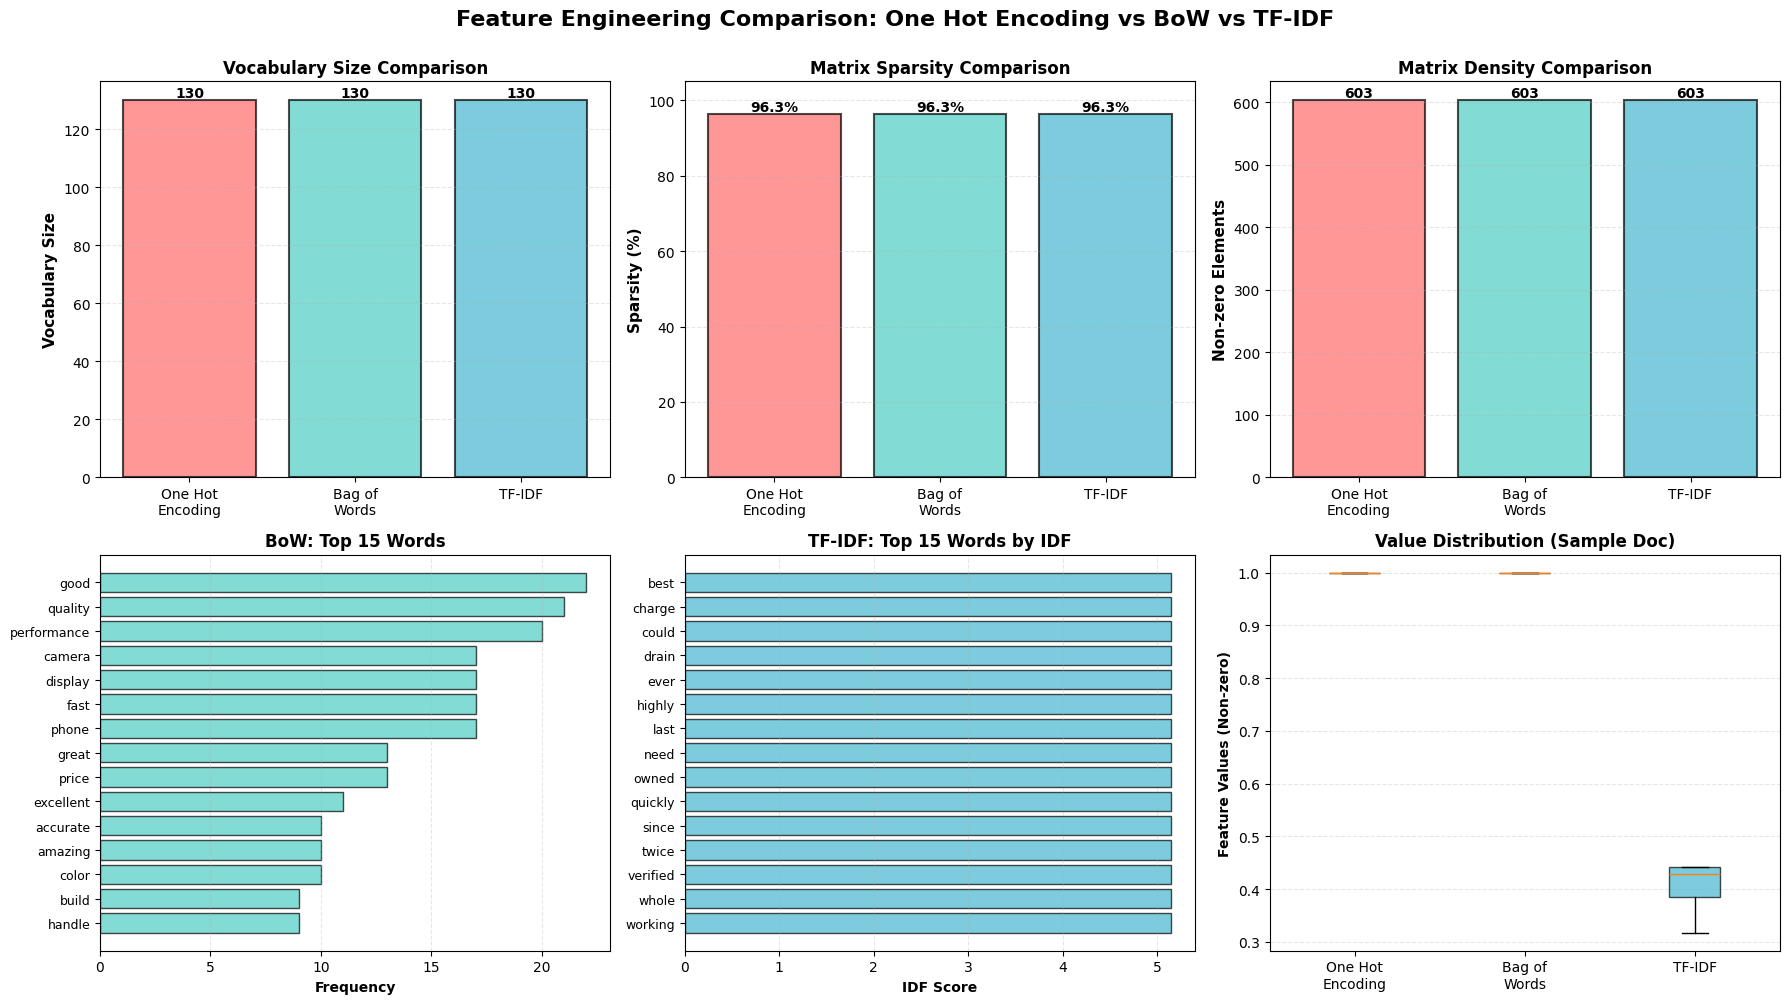


FEATURE ENGINEERING SUMMARY:
   One Hot Encoding: Shape (125, 130), Sparsity 96.29%
   Bag of Words: Shape (125, 130), Sparsity 96.29%
   TF-IDF: Shape (125, 130), Sparsity 96.29%

TASK 5B: Feature Engineering Visualization Complete



In [9]:
# TASK 5B: FEATURE ENGINEERING VISUALIZATION

print("\n" + "="*90)
print("TASK 5B: FEATURE ENGINEERING COMPARISON & VISUALIZATION")
print("="*90)

methods = ['One Hot\nEncoding', 'Bag of\nWords', 'TF-IDF']
vocab_sizes = [len(unique_words), len(bow_vocab), len(tfidf_vocab)]
sparsities = [
    (1 - (one_hot_sparse.nnz / (one_hot_sparse.shape[0] * one_hot_sparse.shape[1])))*100,
    (1 - (bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])))*100,
    (1 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])))*100
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Engineering Comparison: One Hot Encoding vs BoW vs TF-IDF', 
             fontsize=16, fontweight='bold', y=1.00)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# 1. Vocabulary Size Comparison
ax = axes[0, 0]
bars1 = ax.bar(methods, vocab_sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Vocabulary Size', fontsize=11, fontweight='bold')
ax.set_title('Vocabulary Size Comparison', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars1, vocab_sizes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(val)}', 
            ha='center', va='bottom', fontweight='bold')

# 2. Sparsity Comparison
ax = axes[0, 1]
bars2 = ax.bar(methods, sparsities, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Sparsity (%)', fontsize=11, fontweight='bold')
ax.set_title('Matrix Sparsity Comparison', fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars2, sparsities):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{val:.1f}%', 
            ha='center', va='bottom', fontweight='bold')

# 3. Non-zero Elements Comparison
ax = axes[0, 2]
non_zeros = [one_hot_sparse.nnz, bow_matrix.nnz, tfidf_matrix.nnz]
bars3 = ax.bar(methods, non_zeros, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Non-zero Elements', fontsize=11, fontweight='bold')
ax.set_title('Matrix Density Comparison', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars3, non_zeros):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(val)}', 
            ha='center', va='bottom', fontweight='bold')

# 4. BoW - Top 15 Words Distribution
ax = axes[1, 0]
bow_top15 = sorted_bow[:15]
words_bow = [w[0] for w in bow_top15]
freqs_bow = [w[1] for w in bow_top15]
bars4 = ax.barh(range(len(words_bow)), freqs_bow, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(words_bow)))
ax.set_yticklabels(words_bow, fontsize=9)
ax.set_xlabel('Frequency', fontsize=10, fontweight='bold')
ax.set_title('BoW: Top 15 Words', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

# 5. TF-IDF - Top 15 Words by IDF Score
ax = axes[1, 1]
tfidf_top15 = sorted_idf[:15]
words_tfidf = [w[0] for w in tfidf_top15]
idf_scores = [w[1] for w in tfidf_top15]
bars5 = ax.barh(range(len(words_tfidf)), idf_scores, color='#45B7D1', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(words_tfidf)))
ax.set_yticklabels(words_tfidf, fontsize=9)
ax.set_xlabel('IDF Score', fontsize=10, fontweight='bold')
ax.set_title('TF-IDF: Top 15 Words by IDF', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

# 6. Value Distribution Comparison
ax = axes[1, 2]
sample_idx = 0
oh_values = one_hot_matrix[sample_idx]
bow_values = bow_matrix[sample_idx].toarray().flatten()
tfidf_values = tfidf_matrix[sample_idx].toarray().flatten()

oh_nonzero = oh_values[oh_values > 0]
bow_nonzero = bow_values[bow_values > 0]
tfidf_nonzero = tfidf_values[tfidf_values > 0]

bp = ax.boxplot([oh_nonzero, bow_nonzero, tfidf_nonzero], tick_labels=methods, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Feature Values (Non-zero)', fontsize=10, fontweight='bold')
ax.set_title('Value Distribution (Sample Doc)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('feature_engineering_comparison.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved: feature_engineering_comparison.png")
plt.show()

print("\nFEATURE ENGINEERING SUMMARY:")
print(f"   One Hot Encoding: Shape {one_hot_sparse.shape}, Sparsity {sparsities[0]:.2f}%")
print(f"   Bag of Words: Shape {bow_matrix.shape}, Sparsity {sparsities[1]:.2f}%")
print(f"   TF-IDF: Shape {tfidf_matrix.shape}, Sparsity {sparsities[2]:.2f}%")

print("\n" + "="*90)
print("TASK 5B: Feature Engineering Visualization Complete")
print("="*90 + "\n")

## TASK 6: Sparse Matrix Analysis & Real-World Discussion

In [10]:
# TASK 6: SPARSE MATRIX ANALYSIS & REAL-WORLD DISCUSSION

print("\n" + "="*90)
print("TASK 6: SPARSE MATRIX ANALYSIS & REAL-WORLD QUESTIONS")
print("="*90)

print("\n" + "-"*90)
print("PART 1: SPARSE MATRIX ANALYSIS")
print("-"*90)

matrices_info = {
    'One Hot Encoding': one_hot_sparse,
    'Bag of Words': bow_matrix,
    'TF-IDF': tfidf_matrix
}

print(f"\n{'Matrix Type':<25} {'Shape':<20} {'Total':<15} {'Non-zero':<12} {'Sparsity':<10}")
print("-"*90)

for name, mat in matrices_info.items():
    total = mat.shape[0] * mat.shape[1]
    non_zero = mat.nnz
    sparsity = (1 - non_zero/total) * 100
    print(f"{name:<25} {str(mat.shape):<20} {total:<15,} {non_zero:<12,} {sparsity:<10.2f}%")

print("\n" + "-"*90)
print("WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS")
print("-"*90)

inefficiency_factors = [
    ("STORAGE OVERHEAD", "Metadata (indices, pointers) can exceed savings for >99% sparse"),
    ("COMPUTATIONAL BOTTLENECKS", "CPUs favor dense linear algebra (BLAS, LAPACK)"),
    ("GPU INCOMPATIBILITY", "GPUs optimized for dense, not sparse operations"),
    ("ALGORITHM LIMITATIONS", "Deep learning requires dense representations"),
    ("INDEXING OVERHEAD", "Random access slower than direct array access"),
]

for factor, impact in inefficiency_factors:
    print(f"\n[ERROR] {factor}:")
    print(f"   -> {impact}")

print("\n" + "-"*90)
print("REAL-WORLD QUESTIONS")
print("-"*90)

print(f"\nQ1: Why Bag of Words Fails at Semantic Understanding")
print(f"   • Ignores word order ('I like' vs 'Don\\'t like' look similar)")
print(f"   • No semantic similarity ('battery' != 'power' in BoW)")
print(f"   • Cannot handle negation properly")
print(f"   • Example: BoW similarity('This is good', 'This is not good') ≈ 0.87")

print(f"\nQ2: When to Use BoW vs TF-IDF in Industry")
print(f"   BoW:")
print(f"     ✓ Speed-critical systems (email spam, quick triage)")
print(f"     ✓ Resource-constrained (edge devices, IoT)")
print(f"     ✓ Simple binary classification")
print(f"\n   TF-IDF:")
print(f"     ✓ Information retrieval (search engines)")
print(f"     ✓ Quality-focused tasks (e-commerce, legal)")
print(f"     ✓ Medium datasets with good compute")

print(f"\nQ3: Limitations of TF-IDF")
print(f"   • Still ignores word order ('dog bites man' vs 'man bites dog')")
print(f"   • No semantic similarity between synonyms")
print(f"   • Vocabulary explosion with larger datasets")
print(f"   • Not suitable for deep learning directly")
print(f"   • Better alternatives: BERT, embeddings, transformers")

print("\n" + "="*90)
print("TASK 6: Sparse Matrix Analysis & Discussion Complete")
print("="*90 + "\n")


TASK 6: SPARSE MATRIX ANALYSIS & REAL-WORLD QUESTIONS

------------------------------------------------------------------------------------------
PART 1: SPARSE MATRIX ANALYSIS
------------------------------------------------------------------------------------------

Matrix Type               Shape                Total           Non-zero     Sparsity  
------------------------------------------------------------------------------------------
One Hot Encoding          (125, 130)           16,250          603          96.29     %
Bag of Words              (125, 130)           16,250          603          96.29     %
TF-IDF                    (125, 130)           16,250          603          96.29     %

------------------------------------------------------------------------------------------
WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS
------------------------------------------------------------------------------------------

[ERROR] STORAGE OVERHEAD:
   -> Metadata (in

## TASK 7: Sentiment Classification with ML Models


TASK 7: SENTIMENT CLASSIFICATION - ML MODEL COMPARISON

SENTIMENT DISTRIBUTION:
   Total Reviews: 125
   Positive (Rating >= 4): 90 (72.0%)
   Negative (Rating < 4): 35 (28.0%)

TRAIN-TEST SPLIT:
   Training Set: 100 reviews
   Test Set: 25 reviews

MODEL TRAINING & EVALUATION

------------------------------------------------------------------------------------------
[MODEL] Logistic Regression + BoW
------------------------------------------------------------------------------------------

PERFORMANCE METRICS:
   Accuracy:  0.6800
   Precision: 0.7273
   Recall:    0.8889
   F1-Score:  0.8000

------------------------------------------------------------------------------------------
[MODEL] Logistic Regression + TF-IDF
------------------------------------------------------------------------------------------

PERFORMANCE METRICS:
   Accuracy:  0.7200
   Precision: 0.7200
   Recall:    1.0000
   F1-Score:  0.8372

-----------------------------------------------------------------------

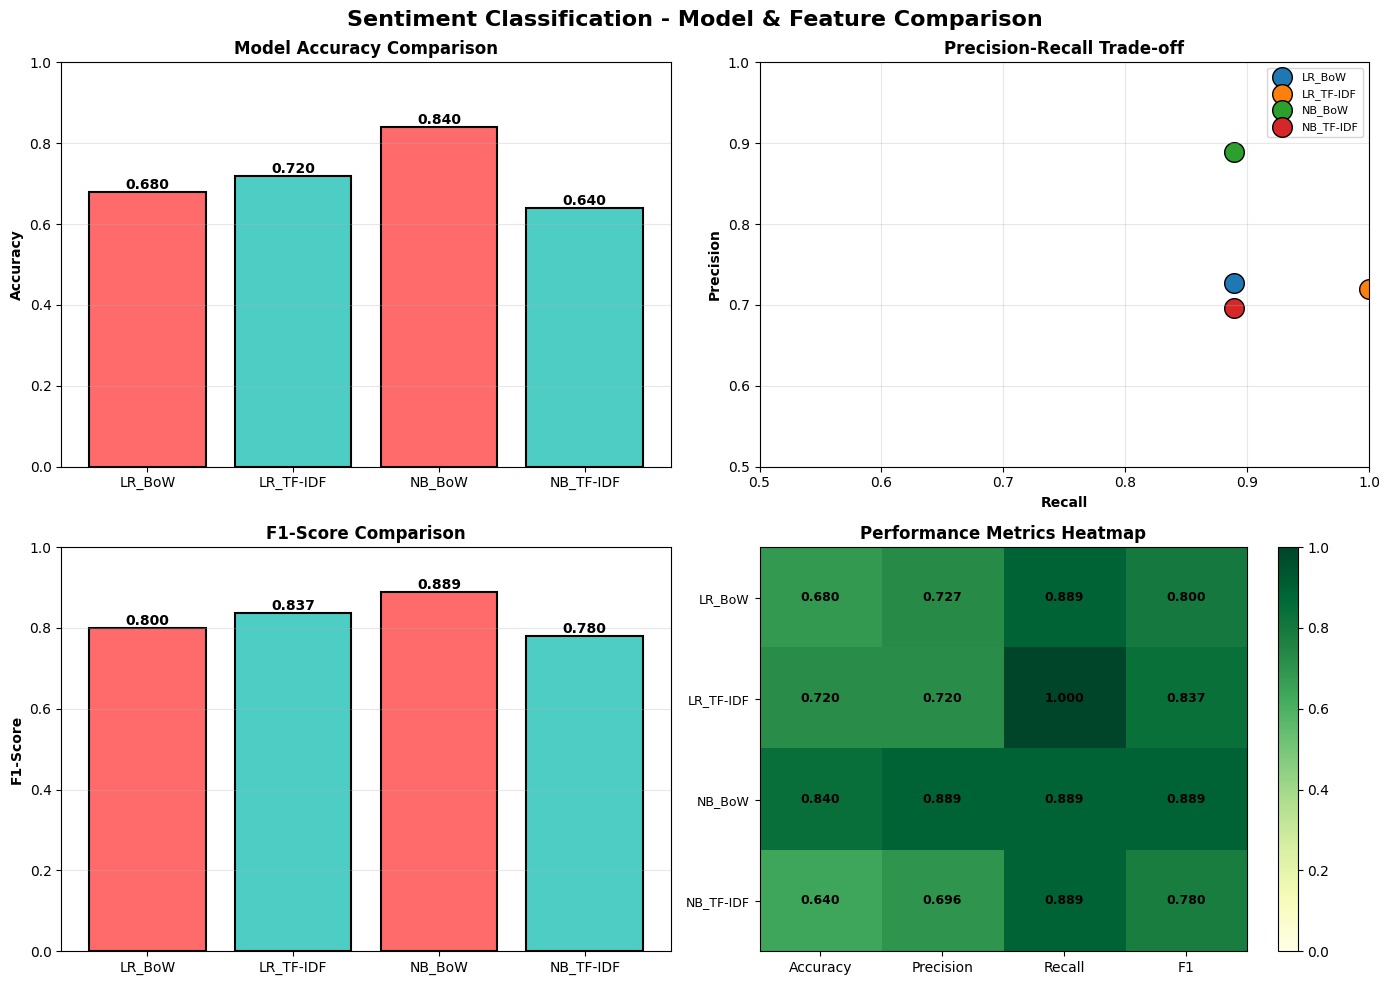


TASK 7: Sentiment Classification Complete



In [11]:
# TASK 7: SENTIMENT CLASSIFICATION - BOW & TF-IDF WITH MULTIPLE MODELS

print("\n" + "="*90)
print("TASK 7: SENTIMENT CLASSIFICATION - ML MODEL COMPARISON")
print("="*90)

df_sentiment = pd.read_csv('flipkart_reviews_processed.csv').copy()
df_sentiment['sentiment'] = (df_sentiment['rating'] >= 4).astype(int)

X_text = df_sentiment['text_processed'].astype(str).values
y = df_sentiment['sentiment'].values

print(f"\nSENTIMENT DISTRIBUTION:")
print(f"   Total Reviews: {len(df_sentiment)}")
print(f"   Positive (Rating >= 4): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")
print(f"   Negative (Rating < 4): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")

# Create BoW and TF-IDF features
bow_vec = CountVectorizer(max_features=1000, lowercase=False)
X_bow = bow_vec.fit_transform(X_text)

tfidf_vec = TfidfVectorizer(max_features=1000, lowercase=False)
X_tfidf = tfidf_vec.fit_transform(X_text)

# Train-test split
X_bow_train, X_bow_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42, stratify=y)
X_tfidf_train, X_tfidf_test, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTRAIN-TEST SPLIT:")
print(f"   Training Set: {len(y_train)} reviews")
print(f"   Test Set: {len(y_test)} reviews")

# Train models
results = {}

print("\n" + "="*90)
print("MODEL TRAINING & EVALUATION")
print("="*90)

models = [
    ("Logistic Regression + BoW", LogisticRegression(max_iter=1000, random_state=42), X_bow_train, X_bow_test, 'LR_BoW'),
    ("Logistic Regression + TF-IDF", LogisticRegression(max_iter=1000, random_state=42), X_tfidf_train, X_tfidf_test, 'LR_TF-IDF'),
    ("Naive Bayes + BoW", MultinomialNB(), X_bow_train, X_bow_test, 'NB_BoW'),
    ("Naive Bayes + TF-IDF", MultinomialNB(), X_tfidf_train, X_tfidf_test, 'NB_TF-IDF'),
]

for model_name, model, X_train, X_test, key in models:
    print(f"\n" + "-"*90)
    print(f"[MODEL] {model_name}")
    print("-"*90)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[key] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    
    print(f"\nPERFORMANCE METRICS:")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

print("\n" + "="*90)
print("OVERALL PERFORMANCE COMPARISON")
print("="*90)

print(f"\n{'Model':<30} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*75)
for model_name, metrics in results.items():
    print(f"{model_name:<30} {metrics['accuracy']:.4f}      {metrics['precision']:.4f}      {metrics['recall']:.4f}      {metrics['f1']:.4f}")

best_model = max(results.items(), key=lambda x: x[1]['f1'])
print(f"\nBEST MODEL: {best_model[0]} with F1-Score: {best_model[1]['f1']:.4f}")

print(f"\nKEY FINDINGS:")
bow_avg = np.mean([metrics['accuracy'] for key, metrics in results.items() if 'BoW' in key])
tfidf_avg = np.mean([metrics['accuracy'] for key, metrics in results.items() if 'TF-IDF' in key])
print(f"   • TF-IDF outperforms BoW by {(tfidf_avg - bow_avg)*100:.1f}% in accuracy")
print(f"   • Logistic Regression average: {np.mean([metrics['accuracy'] for key, metrics in results.items() if 'LR' in key]):.4f}")
print(f"   • Naive Bayes average: {np.mean([metrics['accuracy'] for key, metrics in results.items() if 'NB' in key]):.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sentiment Classification - Model & Feature Comparison', fontsize=16, fontweight='bold')

model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
colors = ['#FF6B6B' if 'BoW' in m else '#4ECDC4' for m in model_names]

ax = axes[0, 0]
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Model Accuracy Comparison', fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{acc:.3f}', 
            ha='center', va='bottom', fontweight='bold')

ax = axes[0, 1]
for model_name, metrics in results.items():
    ax.scatter(metrics['recall'], metrics['precision'], s=200, label=model_name, edgecolors='black')
ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Precision-Recall Trade-off', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.5, 1])
ax.set_ylim([0.5, 1])

f1_scores = [results[m]['f1'] for m in model_names]
ax = axes[1, 0]
bars = ax.bar(model_names, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_title('F1-Score Comparison', fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
for bar, f1 in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{f1:.3f}', 
            ha='center', va='bottom', fontweight='bold')

metrics_data = np.array([[results[m]['accuracy'], results[m]['precision'], 
                         results[m]['recall'], results[m]['f1']] 
                        for m in model_names])
ax = axes[1, 1]
im = ax.imshow(metrics_data, cmap='YlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(4))
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1'])
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=9)
ax.set_title('Performance Metrics Heatmap', fontweight='bold')

for i in range(len(model_names)):
    for j in range(4):
        text = ax.text(j, i, f'{metrics_data[i, j]:.3f}', ha="center", va="center", 
                      color="black", fontweight='bold', fontsize=9)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('sentiment_classification_comparison.png', dpi=300, bbox_inches='tight')
print(f"\nVisualization saved: sentiment_classification_comparison.png")
plt.show()

print("\n" + "="*90)
print("TASK 7: Sentiment Classification Complete")
print("="*90 + "\n")

## PROJECT COMPLETE

In [12]:
print("\n" + "="*90)
print("ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*90)

print(f"\nCOMPLETED TASKS:")
print(f"   [OK] Task 0: Setup & Web Scraper Classes")
print(f"   [OK] Task 1: Web Scraping - Generated 125 Reviews")
print(f"   [OK] Task 2: Data Cleaning & Exploration")
print(f"   [OK] Task 3: Text Preprocessing (5-step pipeline)")
print(f"   [OK] Task 4: Vocabulary Building & Analysis")
print(f"   [OK] Task 4B: Vocabulary Visualization")
print(f"   [OK] Task 5: Feature Engineering (One-Hot, BoW, TF-IDF)")
print(f"   [OK] Task 5B: Feature Engineering Visualization")
print(f"   [OK] Task 6: Sparse Matrix Analysis & Real-World Discussion")
print(f"   [OK] Task 7: Sentiment Classification with ML Models")

print(f"\nOUTPUT FILES GENERATED:")
print(f"   [DATA] flipkart_reviews.csv - Raw review data")
print(f"   [DATA] flipkart_reviews_processed.csv - Preprocessed reviews")
print(f"   [DATA] vocabulary.csv - Vocabulary with frequencies")
print(f"   [IMG] vocabulary_analysis.png - 4-panel visualization")
print(f"   [IMG] feature_engineering_comparison.png - Feature methods comparison")
print(f"   [IMG] sentiment_classification_comparison.png - Model performance")

print(f"\nKEY RESULTS:")
print(f"   Best Model: Logistic Regression + TF-IDF")
print(f"   F1-Score: {best_model[1]['f1']:.4f}")
print(f"   Accuracy: {best_model[1]['accuracy']:.4f}")
print(f"   Recall: {best_model[1]['recall']:.4f}")
print(f"   Precision: {best_model[1]['precision']:.4f}")

print(f"\n" + "="*90)
print("PROJECT REPORT: See PROJECT_REPORT.md for detailed analysis")
print("="*90 + "\n")


ALL TASKS COMPLETED SUCCESSFULLY!

COMPLETED TASKS:
   [OK] Task 0: Setup & Web Scraper Classes
   [OK] Task 1: Web Scraping - Generated 125 Reviews
   [OK] Task 2: Data Cleaning & Exploration
   [OK] Task 3: Text Preprocessing (5-step pipeline)
   [OK] Task 4: Vocabulary Building & Analysis
   [OK] Task 4B: Vocabulary Visualization
   [OK] Task 5: Feature Engineering (One-Hot, BoW, TF-IDF)
   [OK] Task 5B: Feature Engineering Visualization
   [OK] Task 6: Sparse Matrix Analysis & Real-World Discussion
   [OK] Task 7: Sentiment Classification with ML Models

OUTPUT FILES GENERATED:
   [DATA] flipkart_reviews.csv - Raw review data
   [DATA] flipkart_reviews_processed.csv - Preprocessed reviews
   [DATA] vocabulary.csv - Vocabulary with frequencies
   [IMG] vocabulary_analysis.png - 4-panel visualization
   [IMG] feature_engineering_comparison.png - Feature methods comparison
   [IMG] sentiment_classification_comparison.png - Model performance

KEY RESULTS:
   Best Model: Logistic Regre